# **R/S benchmark — PCE training**

This notebook **only** fits and validates the PCE. It reads the `dataset_unique_train` / `dataset_unique_val` files written by [`01_generate_dataset.ipynb`](01_generate_dataset.ipynb).

## **1. Libraries**

In [14]:
%matplotlib inline
import sys
import time
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import dill
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from functions import *
from UQpy.distributions import Normal, JointIndependent

## **2. Random variables and fixed parameters**

Must match [`01_generate_dataset.ipynb`](01_generate_dataset.ipynb). This only rebuilds the distribution object, it draws no new samples.

In [15]:
r_mean = 5.0
r_std  = 0.8
s_mean = 2.0
s_std  = 0.6

n_latent_samples = 2500   # must match stage 1 — it is the filename prefix
n_lambdas        = 4
max_degree       = 3        # maximum total degree of the PCE polynomial basis

r_dist = Normal(loc=r_mean, scale=r_std)
s_dist = Normal(loc=s_mean, scale=s_std)
joint  = JointIndependent(marginals=[r_dist, s_dist])

## **3. Time grid**

Must match times written by [`01_generate_dataset.ipynb`](01_generate_dataset.ipynb).

In [16]:
times = np.linspace(0, 150, 10, endpoint=True)
times

array([  0.        ,  16.66666667,  33.33333333,  50.        ,
        66.66666667,  83.33333333, 100.        , 116.66666667,
       133.33333333, 150.        ])

## **4. Load the datasets and train the PCE at each time step**

In [17]:
print("="*60)
print("TRAINING THE BENCHMARK PCE")
print("="*60)

results = []
for t in times:
    with open(f'{n_latent_samples}_dataset_unique_train_{t}_benchmark.pkl', 'rb') as f:
        df_unique_train = dill.load(f)
    with open(f'{n_latent_samples}_dataset_unique_val_{t}_benchmark.pkl', 'rb') as f:
        df_unique_val = dill.load(f)

    result = train_and_validate_pce_from_dataset_benchmark(
                                                              df_unique_train=df_unique_train,
                                                              df_unique_val=df_unique_val,
                                                              joint=joint,
                                                              time_step=t,
                                                              n_latent_samples=n_latent_samples,
                                                              n_lambdas=n_lambdas,
                                                              max_degree=max_degree,
                                                              output_dir='.',
                                                          )
    result['x_train'] = df_unique_train[['r', 's']].to_numpy()
    results.append(result)

TRAINING THE BENCHMARK PCE

----------------------------------------
TRAINING PCE FOR TIME STEP: 0.0 years
----------------------------------------
1. PCE training dataset has been saved!
2. PCE statistcs has been saved!

----------------------------------------
TRAINING PCE FOR TIME STEP: 16.666666666666668 years
----------------------------------------
1. PCE training dataset has been saved!
2. PCE statistcs has been saved!

----------------------------------------
TRAINING PCE FOR TIME STEP: 33.333333333333336 years
----------------------------------------
1. PCE training dataset has been saved!
2. PCE statistcs has been saved!

----------------------------------------
TRAINING PCE FOR TIME STEP: 50.0 years
----------------------------------------
1. PCE training dataset has been saved!
2. PCE statistcs has been saved!

----------------------------------------
TRAINING PCE FOR TIME STEP: 66.66666666666667 years
----------------------------------------
1. PCE training dataset has bee

## 5. Validation summary

How well the PCE reproduces each lambda, per time step.

In [18]:
validation_summary = pd.concat([r['statistics'] for r in results], ignore_index=True)
validation_summary.insert(0, 'Time (years)', [r['time_step'] for r in results])
validation_summary

,Time (years),MSE λ1,MSE λ2,MSE λ3,MSE λ4,R² λ1,R² λ2,R² λ3,R² λ4
0,0.000000,0.000026,2.728847,0.001742,0.001546,0.999976,0.393163,-0.038968,0.020669
1,16.666667,0.000030,0.280754,0.000557,0.000453,0.999968,0.842451,-0.090681,-0.093229
2,33.333333,0.000029,8.961734,0.004067,0.003880,0.999963,0.293898,-0.028433,-0.020469
3,50.000000,0.000024,5.500992,0.002794,0.002620,0.999965,0.418422,-0.006555,0.012537
4,66.666667,0.000023,3.041105,0.001771,0.001663,0.999959,0.573740,-0.110484,-0.083616
5,83.333333,0.000022,26.017754,0.008388,0.007921,0.999954,0.304588,0.015297,0.030660
6,100.000000,0.000021,15.791484,0.006120,0.006073,0.999950,0.374871,0.004114,0.001836
7,116.666667,0.000022,5.578681,0.002774,0.002683,0.999939,0.624114,-0.008705,0.002108
8,133.333333,0.000023,9.307969,0.002962,0.002834,0.999932,0.579159,-0.063771,-0.035536
9,150.000000,0.000017,13.033269,0.004984,0.004912,0.999946,0.525837,0.005436,0.002964


## 6. Emulator efficiency (speed-up)

Combines this notebook's PCE evaluation time with the emulator cost recorded by [`01_generate_dataset.ipynb`](01_generate_dataset.ipynb).

In [19]:
with open(f'{n_latent_samples}_emulator_timing_benchmark.pkl', 'rb') as f:
    emulator_timing = dill.load(f)

speedup_rows = []
for result in results:
    emulator_s = float(emulator_timing.loc[emulator_timing['Time (years)'] == result['time_step'], 'Train total (s)'].iloc[0])

    t_start = time.perf_counter()
    result['pce_metamodel'].predict(result['x_train'])
    surrogate_s = time.perf_counter() - t_start

    speedup_rows.append({
                            'Time (years)':  result['time_step'],
                            'Emulator (s)':  emulator_s,
                            'Surrogate (s)': surrogate_s,
                            'Speed-up':      emulator_s / surrogate_s,
                        })

speedup = pd.DataFrame(speedup_rows)
print(f"Median speed-up: {speedup['Speed-up'].median():,.0f}x")
speedup

Median speed-up: 7,020x


,Time (years),Emulator (s),Surrogate (s),Speed-up
0,0.000000,2.528570,0.000425,5942.878660
1,16.666667,2.435580,0.000337,7236.472887
2,33.333333,2.526132,0.000339,7446.334943
3,50.000000,2.403864,0.000333,7215.907796
4,66.666667,2.472495,0.000353,6996.266721
5,83.333333,2.357651,0.000384,6135.066221
6,100.000000,2.408820,0.000346,6971.032910
7,116.666667,2.375498,0.000337,7044.334446
8,133.333333,2.406741,0.000368,6532.955231
9,150.000000,2.531925,0.000338,7491.301478


### 6.1 Speed-up over time

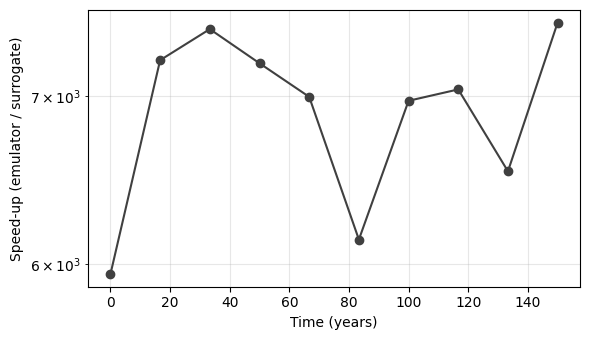

In [20]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(speedup['Time (years)'], speedup['Speed-up'], marker='o', color='0.25')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Speed-up (emulator / surrogate)')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:,.0f}x'))
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()